In [2]:
import pandas as pd

df = pd.read_csv('/content/turkiye-student-evaluation_generic.csv')

df.head()

,instr,class,nb.repeat,attendance,difficulty,Q1,Q2,Q3,Q4,Q5,...,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
0,1,2,1,0,4,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
1,1,2,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,1,2,1,2,4,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
3,1,2,1,1,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
4,1,2,1,0,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5820, 33)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5820 entries, 0 to 5819
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   instr       5820 non-null   int64
 1   class       5820 non-null   int64
 2   nb.repeat   5820 non-null   int64
 3   attendance  5820 non-null   int64
 4   difficulty  5820 non-null   int64
 5   Q1          5820 non-null   int64
 6   Q2          5820 non-null   int64
 7   Q3          5820 non-null   int64
 8   Q4          5820 non-null   int64
 9   Q5          5820 non-null   int64
 10  Q6          5820 non-null   int64
 11  Q7          5820 non-null   int64
 12  Q8          5820 non-null   int64
 13  Q9          5820 non-null   int64
 14  Q10         5820 non-null   int64
 15  Q11         5820 non-null   int64
 16  Q12         5820 non-null   int64
 17  Q13         5820 non-null   int64
 18  Q14         5820 non-null   int64
 19  Q15         5820 non-null   int64
 20  Q16         5820 non-null   in

In [5]:
df.columns

Index(['instr', 'class', 'nb.repeat', 'attendance', 'difficulty', 'Q1', 'Q2',
       'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13',
       'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23',
       'Q24', 'Q25', 'Q26', 'Q27', 'Q28'],
      dtype='object')

In [6]:
# Select the 28 evaluation questions
fa_data = df[[f'Q{i}' for i in range(1, 29)]]

# Display the first 5 rows
fa_data.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
0,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
1,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,5,5,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
3,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
4,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [7]:
print("Shape:", fa_data.shape)

Shape: (5820, 28)


In [8]:
print("Total missing values:", fa_data.isnull().sum().sum())

Total missing values: 0


In [9]:
correlation_matrix = fa_data.corr()

print(correlation_matrix.round(2))

       Q1    Q2    Q3    Q4    Q5    Q6    Q7    Q8    Q9   Q10  ...   Q19  \
Q1   1.00  0.87  0.77  0.85  0.80  0.77  0.79  0.79  0.73  0.80  ...  0.70   
Q2   0.87  1.00  0.85  0.87  0.86  0.83  0.84  0.83  0.80  0.85  ...  0.79   
Q3   0.77  0.85  1.00  0.83  0.84  0.82  0.82  0.81  0.80  0.83  ...  0.80   
Q4   0.85  0.87  0.83  1.00  0.87  0.84  0.84  0.82  0.78  0.84  ...  0.77   
Q5   0.80  0.86  0.84  0.87  1.00  0.88  0.89  0.88  0.81  0.88  ...  0.81   
Q6   0.77  0.83  0.82  0.84  0.88  1.00  0.89  0.86  0.80  0.87  ...  0.79   
Q7   0.79  0.84  0.82  0.84  0.89  0.89  1.00  0.90  0.82  0.89  ...  0.79   
Q8   0.79  0.83  0.81  0.82  0.88  0.86  0.90  1.00  0.83  0.89  ...  0.78   
Q9   0.73  0.80  0.80  0.78  0.81  0.80  0.82  0.83  1.00  0.87  ...  0.79   
Q10  0.80  0.85  0.83  0.84  0.88  0.87  0.89  0.89  0.87  1.00  ...  0.82   
Q11  0.72  0.79  0.81  0.77  0.81  0.80  0.81  0.81  0.83  0.86  ...  0.80   
Q12  0.76  0.80  0.78  0.79  0.82  0.81  0.83  0.84  0.81  0.87 

#HEATMAP

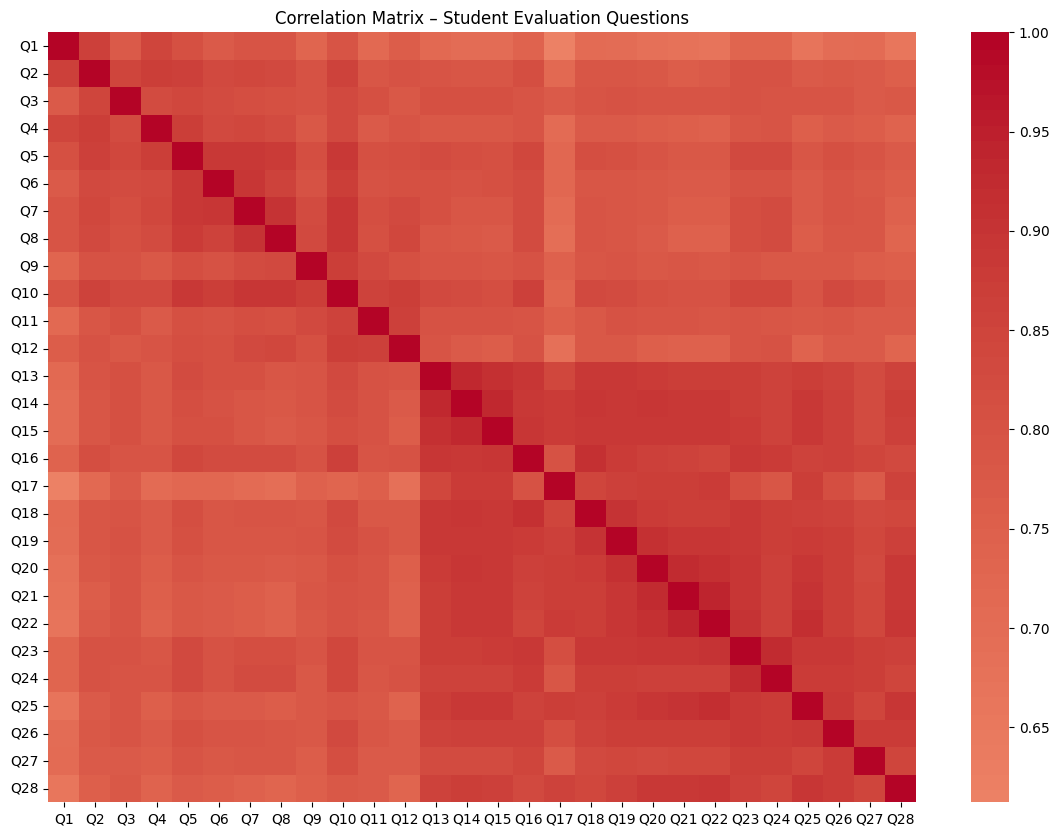

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix – Student Evaluation Questions")
plt.show()

KMO TEST

In [11]:
!pip install factor_analyzer -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


KMO TEST

In [13]:
from factor_analyzer.factor_analyzer import calculate_kmo

kmo_all, kmo_model = calculate_kmo(fa_data)

print("Overall KMO Score:", round(kmo_model, 3))

Overall KMO Score: 0.989


Bartlett

In [14]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

chi_square_value, p_value = calculate_bartlett_sphericity(fa_data)

print("Bartlett's Test Chi-Square:", round(chi_square_value, 3))
print("Bartlett's Test P-Value:", p_value)

Bartlett's Test Chi-Square: 297891.389
Bartlett's Test P-Value: 0.0


Eigenvalues

In [15]:
from factor_analyzer import FactorAnalyzer

# Create Factor Analyzer with all 28 factors initially
fa = FactorAnalyzer(n_factors=28, rotation=None)

# Fit the model
fa.fit(fa_data)

# Get eigenvalues
eigenvalues, variance = fa.get_eigenvalues()

# Display eigenvalues
for i, eigenvalue in enumerate(eigenvalues, start=1):
    print(f"Factor {i}: Eigenvalue = {eigenvalue:.3f}")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Factor 1: Eigenvalue = 23.041
Factor 2: Eigenvalue = 1.253
Factor 3: Eigenvalue = 0.395
Factor 4: Eigenvalue = 0.361
Factor 5: Eigenvalue = 0.290
Factor 6: Eigenvalue = 0.256
Factor 7: Eigenvalue = 0.204
Factor 8: Eigenvalue = 0.183
Factor 9: Eigenvalue = 0.172
Factor 10: Eigenvalue = 0.143
Factor 11: Eigenvalue = 0.138
Factor 12: Eigenvalue = 0.137
Factor 13: Eigenvalue = 0.119
Factor 14: Eigenvalue = 0.116
Factor 15: Eigenvalue = 0.114
Factor 16: Eigenvalue = 0.110
Factor 17: Eigenvalue = 0.106
Factor 18: Eigenvalue = 0.101
Factor 19: Eigenvalue = 0.095
Factor 20: Eigenvalue = 0.093
Factor 21: Eigenvalue = 0.085
Factor 22: Eigenvalue = 0.084
Factor 23: Eigenvalue = 0.080
Factor 24: Eigenvalue = 0.077
Factor 25: Eigenvalue = 0.071
Factor 26: Eigenvalue = 0.068
Factor 27: Eigenvalue = 0.056
Factor 28: Eigenvalue = 0.052


Scree Plot 📈

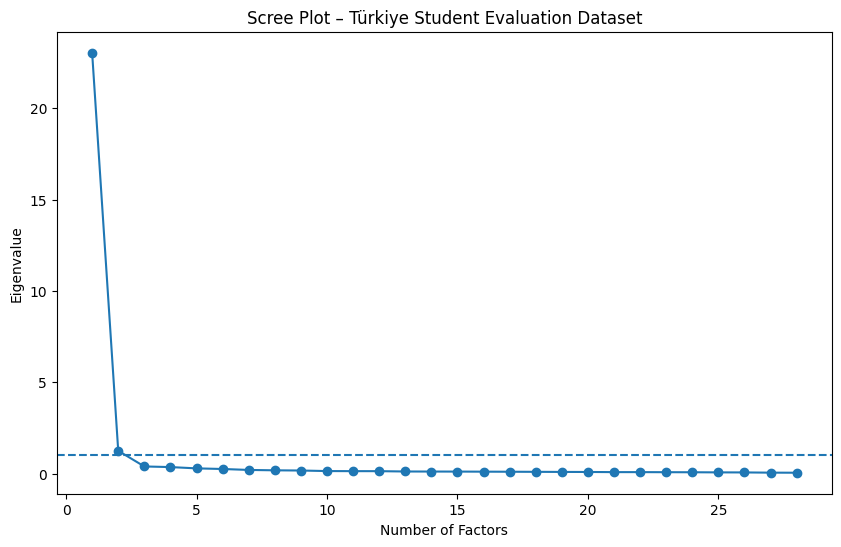

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(eigenvalues) + 1),
    eigenvalues,
    marker='o'
)

plt.axhline(y=1, linestyle='--')

plt.xlabel("Number of Factors")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot – Türkiye Student Evaluation Dataset")

plt.show()

In [18]:
from factor_analyzer import FactorAnalyzer

# Create a Factor Analysis model with 2 factors
fa = FactorAnalyzer(
    n_factors=2,
    rotation='varimax'
)

# Fit the model
fa.fit(fa_data)

# Get factor loadings
loadings = pd.DataFrame(
    fa.loadings_,
    index=fa_data.columns,
    columns=['Factor 1', 'Factor 2']
)

# Display the loadings
print(loadings.round(3))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


     Factor 1  Factor 2
Q1      0.360     0.796
Q2      0.474     0.790
Q3      0.555     0.702
Q4      0.457     0.788
Q5      0.498     0.796
Q6      0.494     0.774
Q7      0.462     0.816
Q8      0.454     0.812
Q9      0.539     0.703
Q10     0.518     0.794
Q11     0.556     0.689
Q12     0.480     0.755
Q13     0.749     0.563
Q14     0.792     0.522
Q15     0.788     0.521
Q16     0.705     0.611
Q17     0.818     0.406
Q18     0.760     0.544
Q19     0.785     0.524
Q20     0.817     0.487
Q21     0.833     0.462
Q22     0.836     0.459
Q23     0.751     0.570
Q24     0.710     0.596
Q25     0.822     0.471
Q26     0.748     0.546
Q27     0.693     0.571
Q28     0.806     0.462


In [19]:
# Get variance explained by each factor
variance = fa.get_factor_variance()

print("Variance Explained:")
print("Factor 1:", round(variance[1][0] * 100, 2), "%")
print("Factor 2:", round(variance[1][1] * 100, 2), "%")

print("Cumulative Variance:",
      round(variance[2][1] * 100, 2), "%")

Variance Explained:
Factor 1: 44.79 %
Factor 2: 40.95 %
Cumulative Variance: 85.74 %


In [20]:
# Display the question descriptions / column names
print(df.columns.tolist())

['instr', 'class', 'nb.repeat', 'attendance', 'difficulty', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28']


In [21]:
# Create a clean factor loading table

loading_table = loadings.copy()

# Add the factor with the strongest loading
loading_table['Assigned Factor'] = loading_table.idxmax(axis=1)

# Add the strongest loading value
loading_table['Highest Loading'] = loading_table[['Factor 1', 'Factor 2']].max(axis=1)

print(loading_table.round(3))

     Factor 1  Factor 2 Assigned Factor  Highest Loading
Q1      0.360     0.796        Factor 2            0.796
Q2      0.474     0.790        Factor 2            0.790
Q3      0.555     0.702        Factor 2            0.702
Q4      0.457     0.788        Factor 2            0.788
Q5      0.498     0.796        Factor 2            0.796
Q6      0.494     0.774        Factor 2            0.774
Q7      0.462     0.816        Factor 2            0.816
Q8      0.454     0.812        Factor 2            0.812
Q9      0.539     0.703        Factor 2            0.703
Q10     0.518     0.794        Factor 2            0.794
Q11     0.556     0.689        Factor 2            0.689
Q12     0.480     0.755        Factor 2            0.755
Q13     0.749     0.563        Factor 1            0.749
Q14     0.792     0.522        Factor 1            0.792
Q15     0.788     0.521        Factor 1            0.788
Q16     0.705     0.611        Factor 1            0.705
Q17     0.818     0.406        

In [22]:
# Calculate factor scores for each observation
factor_scores = fa.transform(fa_data)

# Convert to a DataFrame
factor_scores_df = pd.DataFrame(
    factor_scores,
    columns=['Factor 1 Score', 'Factor 2 Score']
)

# Display the first 5 observations
factor_scores_df.head()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor 1 Score,Factor 2 Score
0,-0.349223,0.128733
1,-0.349223,0.128733
2,0.845358,1.362813
3,-0.349223,0.128733
4,-1.543804,-1.105347


In [23]:
# Check the factor score dataset
print("Shape:", factor_scores_df.shape)

# Statistical summary
print(factor_scores_df.describe())

Shape: (5820, 2)
       Factor 1 Score  Factor 2 Score
count    5.820000e+03    5.820000e+03
mean     2.441728e-18   -4.883455e-17
std      9.742880e-01    9.682754e-01
min     -5.045173e+00   -4.354487e+00
25%     -4.529614e-01   -7.114471e-01
50%      1.612946e-01    1.287329e-01
75%      7.793971e-01    7.457731e-01
max      4.346728e+00    4.611953e+00


Visualize Factor 1 vs Factor 2

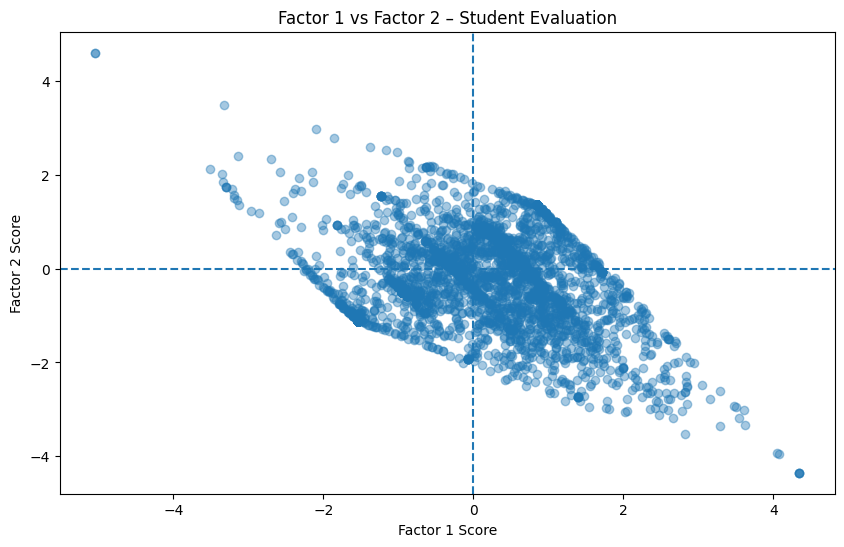

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    factor_scores_df['Factor 1 Score'],
    factor_scores_df['Factor 2 Score'],
    alpha=0.4
)

plt.xlabel("Factor 1 Score")
plt.ylabel("Factor 2 Score")
plt.title("Factor 1 vs Factor 2 – Student Evaluation")

plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')

plt.show()

In [25]:
# Create final factor-loading table

final_loadings = loadings.copy()

# Find the factor with the strongest loading
final_loadings['Assigned Factor'] = final_loadings.idxmax(axis=1)

# Find the strongest loading value
final_loadings['Highest Loading'] = final_loadings[['Factor 1', 'Factor 2']].max(axis=1)

# Display the table
print(final_loadings.round(3))

     Factor 1  Factor 2 Assigned Factor  Highest Loading
Q1      0.360     0.796        Factor 2            0.796
Q2      0.474     0.790        Factor 2            0.790
Q3      0.555     0.702        Factor 2            0.702
Q4      0.457     0.788        Factor 2            0.788
Q5      0.498     0.796        Factor 2            0.796
Q6      0.494     0.774        Factor 2            0.774
Q7      0.462     0.816        Factor 2            0.816
Q8      0.454     0.812        Factor 2            0.812
Q9      0.539     0.703        Factor 2            0.703
Q10     0.518     0.794        Factor 2            0.794
Q11     0.556     0.689        Factor 2            0.689
Q12     0.480     0.755        Factor 2            0.755
Q13     0.749     0.563        Factor 1            0.749
Q14     0.792     0.522        Factor 1            0.792
Q15     0.788     0.521        Factor 1            0.788
Q16     0.705     0.611        Factor 1            0.705
Q17     0.818     0.406        

In [26]:
# Save factor scores
factor_scores_df.to_csv(
    'student_evaluation_factor_scores.csv',
    index=False
)

print("Factor scores saved successfully!")

Factor scores saved successfully!


In [28]:
import os

print(os.path.exists('student_evaluation_factor_scores.csv'))

True


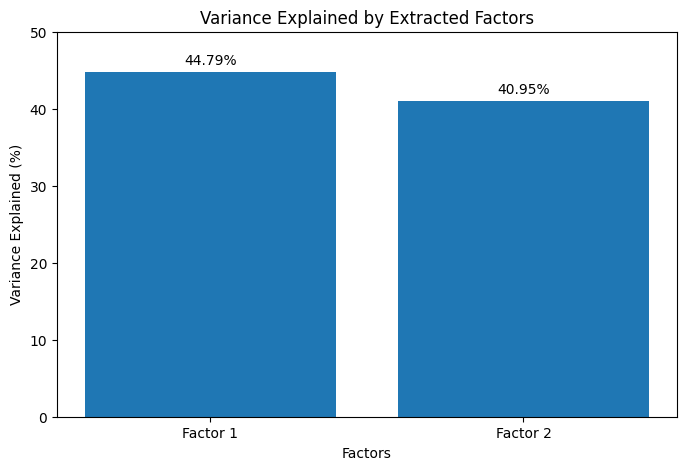

In [29]:
import matplotlib.pyplot as plt

factors = ['Factor 1', 'Factor 2']
variance_explained = [44.79, 40.95]

plt.figure(figsize=(8, 5))

plt.bar(factors, variance_explained)

plt.xlabel("Factors")
plt.ylabel("Variance Explained (%)")
plt.title("Variance Explained by Extracted Factors")

for i, value in enumerate(variance_explained):
    plt.text(i, value + 1, f"{value}%", ha='center')

plt.ylim(0, 50)
plt.show()